### Formulation

The propagator is
$$
\begin{gather*}
    K(q_f, q_i, t)=\langle q_f|e^{-i\hat{H}t/\hbar}|q_i\rangle=\int\mathcal{D}q~e^{iS[q]/\hbar}\\
    S[q]=\int dt~\bigg(\frac{1}{2}m\dot{q}^2-V(q)\bigg)
\end{gather*}
$$
Using the Wick rotation, $t=-i\tau$,
$$
\begin{gather*}
    \dot{q}^2=\bigg(\frac{dq}{dt}\bigg)^2=\bigg(\frac{dq}{d\tau}\frac{1}{-i}\bigg)^2=-\bigg(\frac{dq}{d\tau}\bigg)^2\\
    \frac{i}{\hbar}S[q]=\frac{i}{\hbar}\int -id\tau~\bigg(-\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2-V(q)\bigg)=\frac{-1}{\hbar}\int d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q)\bigg)=\frac{-1}{\hbar}S_E[q]\\
    \therefore K_E(q_f, q_i, \tau)=\langle q_f|e^{-\hat{H}\tau/\hbar}|q_i\rangle=\int\mathcal{D}q~e^{-S_E[q]/\hbar}
\end{gather*}
$$
with the Euclidean action $S_E$,
$$
\begin{gather*}
    S_E[q]=\int_0^\tau d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q(\tau))\bigg)
\end{gather*}
$$
This Formulation implies connection to statistical physics. The partition function is
$$
\begin{gather*}
    Z=\mathrm{tr}(e^{-\beta\hat{H}})=\int dq~\langle q|e^{-\beta\hat{H}}|q\rangle
\end{gather*}
$$
If we replace $\tau=\hbar\beta$,
$$
\begin{gather*}
    Z=\int dq~\langle q|e^{-\beta\hat{H}}|q\rangle=\int dq~K_E(q, q, \hbar\beta)=\int\mathcal{D}q~e^{-S_E[q]/\hbar},\quad q(0)=q(\hbar\beta)
\end{gather*}
$$
$S_E$ can be discretized as
$$
\begin{gather*}
    S_E[q]=\int_0^\tau d\tau~\bigg(\frac{1}{2}m\bigg(\frac{dq}{d\tau}\bigg)^2+V(q(\tau))\bigg)\approx h\sum_i\bigg(\frac{1}{2}m\bigg(\frac{q_{i+1}-q_i}{h}\bigg)^2+V(q_i)\bigg)
\end{gather*}
$$
with $\tau_i=ih$ and $q_i=q(\tau_i)$. $h$ is the imaginary time step. After local update at certain site $j$, $q_j\to q_j+\eta$, the differecne of Euclidean action is
$$
\begin{align*}
    \Delta S_E/h=(S_E[q+\eta]-S_E[q])/h&=\frac{m}{2}\bigg(\bigg(\frac{q_{j+1}-(q_j+\eta)}{h}\bigg)^2 - \bigg(\frac{q_{j+1}-q_j}{h}\bigg)^2 + \bigg(\frac{(q_j+\eta) - q_{j-1}}{h}\bigg)^2 - \bigg(\frac{q_j - q_{j-1}}{h}\bigg)^2\bigg)+V(q_j+\eta)-V(q_j)\\
    &=\frac{m}{2h^2}\bigg((q_{j+1}-q_j-\eta)^2 - (q_{j+1}-q_j)^2 + (q_j+\eta - q_{j-1})^2 - (q_j - q_{j-1})^2\bigg)+V(q_j+\eta)-V(q_j)\\
    &=\frac{m}{2h^2}\bigg(q_{j+1}^2+q_j^2+\eta^2-2q_{j+1}q_j-2q_{j+1}\eta+2q_j\eta-q_{j+1}^2-q_j^2+2q_{j+1}q_j\\
    &\qquad\quad+ q_j^2+q_{j-1}^2+\eta^2+2q_j\eta-2q_jq_{j-1}-2q_{j-1}\eta - q_j^2-q_{j-1}^2+2q_jq_{j-1}\bigg)+V(q_j+\eta)-V(q_j)\\
    \Delta S_E&=\frac{m}{h}(\eta^2-\eta(q_{j+1}-2q_j+q_{j-1}))+h(V(q_j+\eta)-V(q_j))\\
\end{align*}
$$


In [2]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
class pathIntegral_particle:
    def __init__(self, N, dt, delta, V):
        self.N = N
        self.dt = dt
        self.delta = delta
        self.V = V

        self.q = nr.randn(N)
        self.beta = self.N*self.dt # inverse temperature


    def S_E(self):
        # Euclidean action or Energy of system

        v = np.roll(self.q, -1) - self.q
        S = np.sum(0.5*v*v/self.dt + self.V(self.q)*self.dt)

        return S
    

    def Metropolis(self, r=0.1):
        # Metropolis altorithm

        j = nr.randint(self.N) # Random index for update
        eta = nr.uniform(-self.delta, self.delta) # Random displacement at q[j]

        # Difference of S_E after local update
        jp = (j+1)%self.N
        jm = (j-1)%self.N
        dS = 1/self.dt*(eta*eta - eta*(self.q[jp] - 2*self.q[j] + self.q[jm])) + self.dt*(self.V(self.q[j]+eta) - self.V(self.q[j]))

        if (dS <= 0) or (nr.rand() < np.exp(-dS)):
            # Acceptance condition
            self.q[j] += eta

            return 1 
        
        else:
            return 0


    def MonteCarlo(self, eq_sweeps=10**5, MC_sweeps=5*10**5):
        acceptance = 0 # number of acceptance event
        ensemble = []

        # Equilibriate steps
        print("Equilibriate steps")
        for _ in tqdm(range(eq_sweeps)):
            for _ in range(self.N):
                self.Metropolis()

        # Monte Carlo steps
        print("Monte Carlo steps")
        for i in tqdm(range(MC_sweeps)):
            for _ in range(self.N):
                acceptance += self.Metropolis()

            if i%100 == 0:
                # 1 ensemble sampling per 100 sweep
                ensemble.append(np.copy(self.q))

        acceptanceRate = acceptance/(MC_sweeps*self.N)

        q_ensemble = np.array(ensemble)

        return acceptanceRate, q_ensemble
    

def G(q_ensemble, tau):
    # Correlation function
    C = np.zeros_like(tau, dtype=float)

    for i, t in enumerate(tau):
        q_tau = np.roll(q_ensemble, -t, axis=1)
        C[i] = np.mean(q_ensemble*q_tau)

    return C

### 1. Harmonic oscillator

The quantum harmonic oscillator is
$$
\begin{gather*}
    V(q)=\frac{1}{2}m\omega^2q^2
\end{gather*}
$$
The ground state wave function and probability density are
$$
\begin{gather*}
    \psi_0(q)=\bigg(\frac{m\omega}{\pi\hbar}\bigg)^{1/4}\exp\bigg(-\frac{m\omega q^2}{2\hbar}\bigg),\quad|\psi_0(q)|^2=\bigg(\frac{m\omega}{\pi\hbar}\bigg)^{1/2}\exp\bigg(-\frac{m\omega q^2}{\hbar}\bigg)
\end{gather*}
$$
For convenience, we choosed the dimensionless unit $m=\hbar=1$. Then,
$$
\begin{gather*}
    V(q)=\frac{1}{2}\omega^2q^2,\quad |\psi_0(q)|^2=\bigg(\frac{\omega}{\pi}\bigg)^{1/2}e^{-\omega q^2}
\end{gather*}
$$
The correlation function $G(\tau)$ is given by
$$
\begin{align*}
    G(\tau)=\langle q(\tau)q(0)\rangle
\end{align*}
$$
In the operator formalism, $\hat{q}(\tau)=e^{H\tau}\hat{q}(0)e^{-H\tau}=e^{H\tau}\hat{q}e^{-H\tau},~(\hat{q}(0)=\hat{q})$. Therefore,
$$
\begin{align*}
    G(\tau)=\langle q(\tau)q(0)\rangle=\langle 0|e^{H\tau}\hat{q}e^{-H\tau}\hat{q}|0\rangle
\end{align*}
$$
Here, we can use the orthornomal relation and energy spectrum of quantum harmonic oscillator
$$
\begin{align*}
    &I=\sum_n|n\rangle\langle n|,~E_n=\omega\bigg(n+\frac{1}{2}\bigg)\\
    G(\tau)&=\langle 0|e^{H\tau}\hat{q}e^{-H\tau}\hat{q}|0\rangle=\sum_n\langle 0|e^{H\tau}\hat{q}|n\rangle\langle n|e^{-H\tau}\hat{q}|0\rangle\\
    &=\sum_n\langle 0|e^{E_0\tau}\hat{q}|n\rangle\langle n|e^{-E_n\tau}\hat{q}|0\rangle=\sum_ne^{(E_0-E_n)\tau}|\langle n|\hat{q}|0\rangle|^2
\end{align*}
$$
Also, using the creation operator $\hat{a}^\dagger$ and annihilation operator $\hat{a}$,
$$
\begin{gather*}
    \hat{q}=\frac{1}{\sqrt{2\omega}}(\hat{a}+\hat{a}^\dagger)\\
    \langle n|\hat{q}|0\rangle=\frac{1}{\sqrt{2\omega}}\langle n|(\hat{a}+\hat{a}^\dagger)|0\rangle=\frac{1}{\sqrt{2\omega}}\delta_{n,1}\\
    G(\tau)=\frac{1}{2\omega}\sum_ne^{(E_0-E_n)\tau}\delta_{n,1}=\frac{1}{2\omega} e^{(E_0-E_1)\tau}=\frac{1}{2\omega} e^{-\omega\tau}
\end{gather*}
$$
Form this $G(\tau)$, we can extract $\omega$. 
$$
\begin{gather*}
    \frac{G(\tau)}{G(\tau+h)}=\frac{e^{-\omega\tau}}{e^{-\omega(\tau+h)}}=e^{\omega h}\\
    \omega_\text{eff}=\frac{1}{h}\ln\frac{G(\tau)}{G(\tau+h)}
\end{gather*}
$$


In [3]:
class HarmonicOscillator:
    def __init__(self, w):
        self.w = w

    
    def __call__(self, q):
        return 0.5*(self.w**2)*(q**2)


def P0(q, w):
    # |\psi_0(q)|^2
    return np.sqrt(w/np.pi)*np.exp(-w*q*q)

In [4]:
w = 2
N = 100
h = 0.1
delta = 0.5

sim1 = pathIntegral_particle(N, h, delta, HarmonicOscillator(w))
acceptance_rate, q_ensemble = sim1.MonteCarlo()
print(acceptance_rate)

Equilibriate steps


100%|██████████| 100000/100000 [00:36<00:00, 2722.04it/s]


Monte Carlo steps


100%|██████████| 500000/500000 [03:05<00:00, 2701.44it/s]

0.59202914


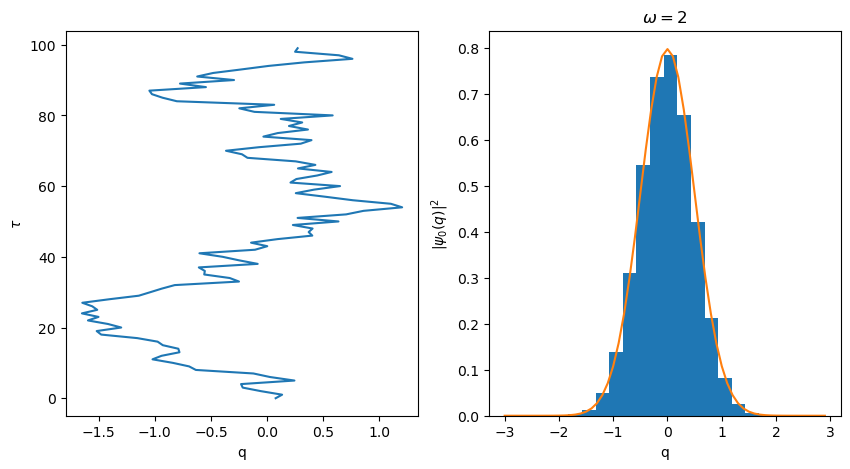

<q^2>
Exact value=0.25
Numerical value=0.24903693802390978


In [ ]:
fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.plot(sim1.q, range(sim1.N))
plt.xlabel('q')
plt.ylabel('$\\tau$')

plt.subplot(122)
q_list = np.arange(-3, 3, 0.1)
p = P0(q_list, w)
plt.hist(q_ensemble.flatten(), bins=20, density=True)
plt.plot(q_list, p)
plt.xlabel('q')
plt.ylabel('$|\\psi_0(q)|^2$')
plt.title("$\\omega=$"+f"{w}")

plt.show()

q2_mean = np.mean(q_ensemble.flatten()**2)
print("<q^2>")
print(f"Exact value={1/(2*w)}")
print(f"Numerical value={q2_mean}")

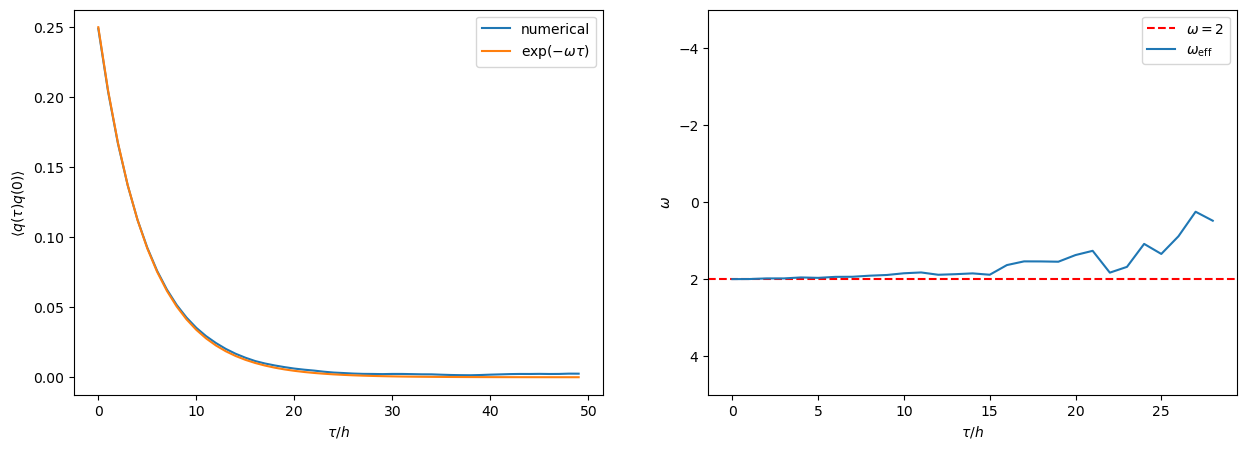

In [11]:
tau = np.arange(0, sim1.N//2)
C = G(q_ensemble, tau)
C_exact = 1/(2*w)*np.exp(-w*tau*sim1.dt)

w_eff = np.log(C[:29]/C[1:30])/sim1.dt

fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.plot(tau, C, label='numerical')
plt.plot(tau, C_exact, label='$\\exp(-\\omega\\tau)$')
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\langle q(\\tau)q(0)\\rangle$')
plt.legend()

plt.subplot(122)
plt.axhline(w, color='r', linestyle='--', label="$\\omega=$"+f"{w}")
plt.plot(w_eff, label="$\\omega_\\text{eff}$")
plt.xlabel('$\\tau/h$')
plt.ylabel('$\\omega$')
plt.ylim(5, -5)
plt.legend()

plt.show()

### 2. Double well potential

Next case is the Double well potential or Higgs potential defined as
$$
\begin{gather*}
    V(q)=\frac{\lambda}{2}(q^2-a^2)^2
\end{gather*}
$$
This potential has global minimum at $q=\pm a$. Unlike to harmonic oscillator, this case does not have analytic solution. Therefore, we need another numerical simulation using FDM. The Shrodinger eqution is given as (dimensionless unit with $m=\hbar=1$)
$$
\begin{gather*}
    -\frac{1}{2}\frac{\partial^2}{dq^2}\psi_n(q) + \frac{\lambda}{2}(q^2-a^2)^2\psi_n(q)=E_n\psi_n(q)
\end{gather*}
$$
Using $q\to q_i$, $V_i=V(q_i)$ and $\psi_i=\psi_n(q_i)$ (we ommited $n$ for convenience),
$$
\begin{align*}
    E\psi_i&=-\frac{1}{2}\frac{\psi_{i+1}+\psi_{i-1}-2\psi_i}{\Delta x^2} + V_i\psi_i\\
    &=-\frac{1}{2\Delta x^2}\psi_{i-1}-\frac{1}{2\Delta x^2}\psi_{i+1}+\bigg(\frac{1}{\Delta x^2} + V_i\bigg)\psi_i\\
    &=L_i\psi_{i-1} + R_i\psi_{i+1} + D_i\psi_i
\end{align*}
$$
The boundary condition is $\psi_n(q\to\pm\infty)=0$. However, in the numerical simulation, system is alway finite so we should use $\psi_n(\pm L)=0$, or in the discretized formulation, $\psi_0=\psi_N=0$ with the system size $2L$.

In [4]:
class DoubleWellPotential:
    def __init__(self, a, l):
        self.a = a # Location of minimum
        self.l = l # Energy barrier depth

    
    def __call__(self, q):
        return self.l*(q**2 - self.a**2)**2

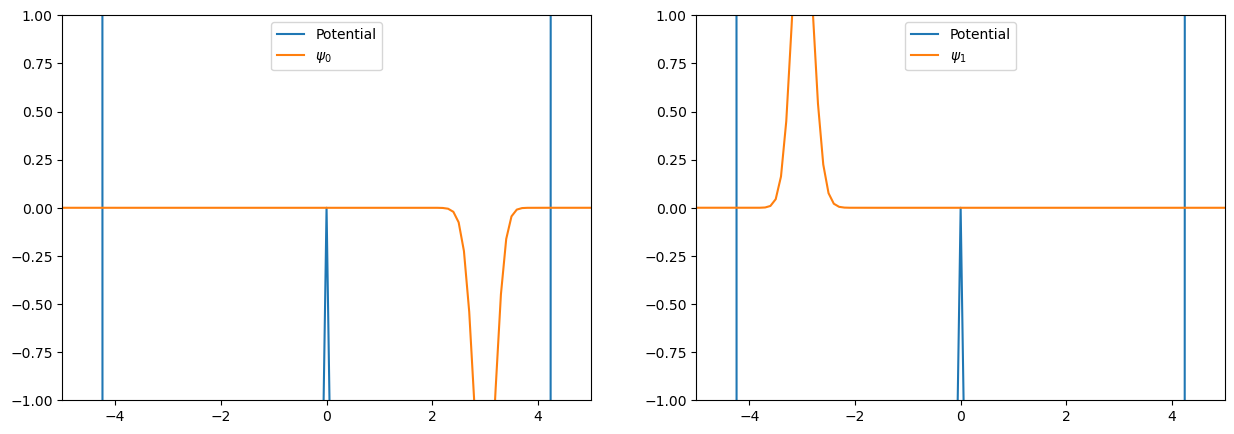

E0=13.160927984214092
E1=13.160927984214217


In [5]:
# FDM for double well
L = 30
dx = 0.1
x = np.arange(-L, L+dx, dx)

a = 3
#l = 0.01
l = 10
V = DoubleWellPotential(a, l)(x)

Di = 1/dx**2 + V
Li = -1/(2*dx**2)*np.ones_like(x)
Ri = -1/(2*dx**2)*np.ones_like(x)

H = np.diag(Di) + np.diag(Li[1:], -1) + np.diag(Ri[:-1], 1) 

E, psi = np.linalg.eigh(H)
order = np.argsort(E)
E = E[order]
psi = psi[:, order]
norms = np.sum(np.abs(psi)**2, axis=0)*dx
psi /= np.sqrt(norms)


E0 = E[0]
psi_0 = psi[:, 0]
p0 = np.abs(psi_0)**2

E1 = E[1]
psi_1 = psi[:, 1]
p1 = np.abs(psi_1)**2

fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.plot(x, V-l*a**4, label='Potential')
plt.plot(x, psi_0, label=f'$\psi_0$')
plt.xlim((-5, 5))
plt.ylim((-1, 1))
plt.legend()

plt.subplot(122)
plt.plot(x, V-l*a**4, label='Potential')
plt.plot(x, psi_1, label=f'$\psi_1$')
plt.xlim((-5, 5))
plt.ylim((-1, 1))
plt.legend()
plt.show()

print(f"E0={E0}")
print(f"E1={E1}")

In [6]:
N = 100
h = 0.1
delta = 0.3

sim2 = pathIntegral_particle(N, h, delta, DoubleWellPotential(a, l))
acceptance_rate, q_ensemble = sim2.MonteCarlo()
print(acceptance_rate)

Equilibriate steps


100%|██████████| 100000/100000 [00:37<00:00, 2673.49it/s]


Monte Carlo steps


100%|██████████| 500000/500000 [03:09<00:00, 2644.98it/s]

0.538487


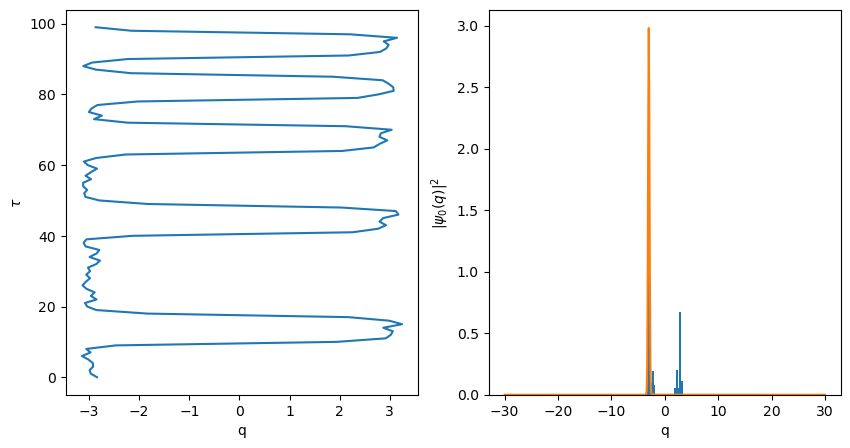

<q^2>
Value from path integral=8.013371722223852
Value form FDM=8.013371722223852


In [ ]:
fig = plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.plot(sim2.q, range(sim2.N))
plt.xlabel('q')
plt.ylabel('$\\tau$')

plt.subplot(122)
plt.hist(q_ensemble.flatten(), bins=20, density=True)
plt.plot(-x, p0)
plt.xlim((-5, 5))
plt.xlabel('q')
plt.ylabel('$|\\psi_0(q)|^2$')

plt.show()

q2_mean = np.mean(q_ensemble.flatten()**2)
q2 = np.sum(x*x*psi_0*psi_0)*dx
print("<q^2>")
print(f"Value from path integral={q2_mean}")
print(f"Value form FDM={q2_mean}")